In [48]:
# !pip install pandas seaborn matplotlib numpy scipy scikit-learn pyarrow

In [49]:
pip install arch

Note: you may need to restart the kernel to use updated packages.


In [50]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import itertools
import pyarrow
import seaborn as sns
from arch import arch_model

Funções

In [51]:
def interpolacao(dataframe: pd.DataFrame) -> pd.DataFrame:

    ativosRemover = []
    interpolacao = []

    tickers = dataframe['Ticker'].unique()

    for ativo in tickers:

        dadosAtivo = (
            dataframe[dataframe['Ticker'] == ativo]
            .copy()
            .sort_values('Date')
        )

        nanMask = dadosAtivo['Close'].isna()

        totalNan = nanMask.sum()

        grupos = (
            nanMask.ne(nanMask.shift())
            .cumsum()
        )

        gaps = nanMask.groupby(grupos).sum()

        maiorGap = gaps.max()

        if maiorGap >= 8:

            ativosRemover.append(ativo)
            continue

        if totalNan > 100:

            ativosRemover.append(ativo)
            continue

        # Pequenos gaps
        dadosAtivo['Close'] = (
            dadosAtivo['Close']
            .ffill(limit=3)
        )

        # Gaps médios
        dadosAtivo['Close'] = (
            dadosAtivo['Close']
            .interpolate(limit=7)
        )

        interpolacao.append(dadosAtivo)

    dataframeInterpolado = pd.concat(interpolacao)

    dataframeInterpolado = dataframeInterpolado[
        ~dataframeInterpolado['Ticker'].isin(ativosRemover)
    ]

    return dataframeInterpolado

In [52]:
def calculoGarch( dataframe: pd.DataFrame, dia: pd.Timestamp) -> pd.DataFrame:

    vol = []

    tickers = dataframe['Ticker'].unique()

    for ativo in tickers:

        dadosAtivo = (
            dataframe[dataframe['Ticker'] == ativo]
            .copy()
            .sort_values('Date')
        )

        # Retornos log
        dadosAtivo['Retorno'] = np.log(
            dadosAtivo['Close'] /
            dadosAtivo['Close'].shift(1)
        )

        dadosAtivo = dadosAtivo.dropna()

        # GARCH precisa de alguns dados mínimos
        if len(dadosAtivo) < 100:
            raise ValueError('Dado com poucos dados encontrado, função interpolação falhou')

        try:

            modelo = arch_model(
                dadosAtivo['Retorno'] * 100,
                vol='Garch',
                p=1,
                q=1
            )

            ajuste = modelo.fit(
                disp='off'
            )

            # Última volatilidade condicional
            garchVol = (
                ajuste
                .conditional_volatility
                .iloc[-1]
            )

            vol.append({
                'Date': dia,
                'Ticker': ativo,
                'GARCH': garchVol
            })

        except:

            continue

    return pd.DataFrame(vol)

In [53]:
def calculoIndicador(dataframe: pd.DataFrame,
                     t1: list,
                     t2: list,
                     t3: list,
                     dia: pd.Timestamp) -> pd.DataFrame:
        
    resultado = []

    indicadores = [t1, t2, t3]

    tickers = dataframe['Ticker'].unique()

    for ativo in tickers:

        dadosAtivo = (
            dataframe[dataframe['Ticker'] == ativo]
            .copy()
            .sort_values('Date')
        )

        linhaResultado = {
            'Date': dia,
            'Ticker': ativo
        }

        for i, indicador in enumerate(indicadores):

            nome = indicador[0]
            periodo = indicador[1]

            valor = np.nan

            # RSI
            if nome == 'RSI':

                delta = dadosAtivo['Close'].diff()

                gain = delta.clip(lower=0)
                loss = -delta.clip(upper=0)

                avg_gain = (
                    gain
                    .rolling(periodo)
                    .mean()
                )

                avg_loss = (
                    loss
                    .rolling(periodo)
                    .mean()
                )

                rs = avg_gain / avg_loss

                rsi = 100 - (100 / (1 + rs))

                valor = rsi.iloc[-1]

            # MACD
            elif nome == 'MACD':

                ema12 = (
                    dadosAtivo['Close']
                    .ewm(span=12, adjust=False)
                    .mean()
                )

                ema26 = (
                    dadosAtivo['Close']
                    .ewm(span=periodo, adjust=False)
                    .mean()
                )

                macd = ema12 - ema26

                valor = macd.iloc[-1]

            # DMA
            elif nome == 'DMA':

                sma = (
                    dadosAtivo['Close']
                    .rolling(periodo)
                    .mean()
                )

                dma = (
                    dadosAtivo['Close'] /
                    sma
                ) - 1

                valor = dma.iloc[-1]

            linhaResultado[f'T{i+1}'] = valor

        resultado.append(linhaResultado)

    return pd.DataFrame(resultado)

In [54]:
def calcularPorAtivo(serieTemporal: pd.DataFrame, t1: list, t2:list, t3:list, dia: pd.Timestamp, tickers: list) -> list:

    # Caso seja sáb aou domingo, pulamos

    # Sabado = 5
    # Domingo = 6

    if dia.weekday() >= 5:

        return pd.DataFrame()
    
    # RETORNO D+1

    # Sexta -> segunda
    if dia.weekday() == 4:

        proximoDia = dia + pd.Timedelta(days=3)
    else:
        proximoDia = dia + pd.Timedelta(days=1)

    # Preço hoje
    precoHoje = (
        serieTemporal[
            serieTemporal['Date'] == dia
        ][['Ticker', 'Close']]
        .rename(columns={'Close': 'CloseHoje'})
    )

    # Preço futuro
    precoFuturo = (
        serieTemporal[
            serieTemporal['Date'] == proximoDia
        ][['Ticker', 'Close']]
        .rename(columns={'Close': 'CloseFuturo'})
    )

    # Merge
    retornoD1 = precoHoje.merge(
        precoFuturo,
        on='Ticker',
        how='inner'
    )

    # Retorno log
    retornoD1['Retorno_D1'] = np.log(
        retornoD1['CloseFuturo'] /
        retornoD1['CloseHoje']
    )

    retornoD1['Date'] = dia

    retornoD1 = retornoD1[
        ['Date', 'Ticker', 'Retorno_D1']
    ]
    
    # Evitar lookahead

    # Pegamos a data atual e 253 dias atrás (otimização)
    serieTemporal = serieTemporal[serieTemporal['Ticker'].isin(tickers)]
    serieTemporal = serieTemporal[(serieTemporal['Date'] >= dia - pd.Timedelta(days=253)) & (serieTemporal['Date'] <= dia)]

    serieTemporalPreenchida = interpolacao(serieTemporal) # Ativos que tem os dados completos para montar os indicadores técnicos e vol

    # filtro duro -> Penny stocks ou preços > 1000 no passado

    serieSuja = serieTemporalPreenchida[(serieTemporalPreenchida['Close'] < 1) | (serieTemporalPreenchida['Close'] > 1000)]
    ativosProblematicos = serieSuja['Ticker'].unique()
    serieLimpa = serieTemporalPreenchida[~serieTemporalPreenchida['Ticker'].isin(ativosProblematicos)]

    # Calculando o Garch, T1, T2 e T3 para o dia: str (x)

    garchVol = calculoGarch(serieLimpa, dia)
    indicadores = calculoIndicador( serieLimpa , t1 , t2, t3 , dia)

    # Retornando date = diaAtual | ticker | garchVol | t1 | t2 | t3 | retornoLogD+1

    datasetDiario = (
    garchVol
    .merge(
        indicadores,
        on=['Date', 'Ticker'],
        how='inner'
    )
    .merge(
        retornoD1,
        on=['Date', 'Ticker'],
        how='inner'
    )
    )

    datasetDiario = datasetDiario.dropna()

    return datasetDiario

Fonte de dados e Tratamento

In [55]:
# Importando os dados - Series temporais que contém os dados dos ativos

seriesTemporais = pd.read_parquet('./source/serieTemporal.parquet')

In [56]:
seriesTemporais = seriesTemporais.rename(columns={'Adj Close': 'Close'})
seriesTemporais = seriesTemporais.sort_values(['Ticker', 'Date'])

<Axes: >

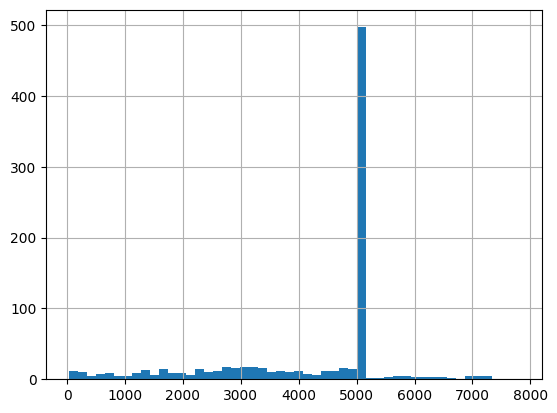

In [57]:
obsPorTicker = (
    seriesTemporais
    .groupby('Ticker')
    .size()
    .sort_values()
)

obsPorTicker.hist(bins=50)

In [58]:
display(seriesTemporais[['Close', 'Volume']].describe())

,Close,Volume
count,3.741998e+06,3.741998e+06
mean,1.880999e+02,5.775332e+06
std,8.548544e+03,3.338895e+07
min,0.000000e+00,0.000000e+00
25%,1.736922e+01,4.239000e+05
50%,3.466581e+01,1.475082e+06
75%,7.115811e+01,3.916500e+06
max,1.330000e+06,3.692928e+09


In [59]:
seriesTemporais.head()

,Date,Ticker,Close,Volume
0,2006-01-03,A,19.978300,5307088.0
1,2006-01-04,A,20.031965,4195817.0
2,2006-01-05,A,20.556767,4835402.0
3,2006-01-06,A,20.664110,6146307.0
4,2006-01-09,A,20.604471,4082859.0


In [60]:
# Todas as datas possíveis
datas = pd.date_range(
    start=seriesTemporais['Date'].min(),
    end=seriesTemporais['Date'].max(),
    freq='D'
)

# Todos os tickers
tickers = seriesTemporais['Ticker'].unique()

# Produto cartesiano entre datas e tickers
baseCompleta = pd.MultiIndex.from_product(
    [datas, tickers],
    names=['Date', 'Ticker']
).to_frame(index=False)

# Merge com a base original
seriesTemporais = baseCompleta.merge(
    seriesTemporais,
    on=['Date', 'Ticker'],
    how='left'
)

display(seriesTemporais)

,Date,Ticker,Close,Volume
0,1995-01-31,A,NaN,NaN
1,1995-01-31,AABA,NaN,NaN
2,1995-01-31,AAL,NaN,NaN
3,1995-01-31,AAP,NaN,NaN
4,1995-01-31,AAPL,NaN,NaN
...,...,...,...,...
10146355,2026-04-17,YUM,NaN,NaN
10146356,2026-04-17,ZBH,NaN,NaN
10146357,2026-04-17,ZBRA,NaN,NaN
10146358,2026-04-17,ZION,NaN,NaN


In [61]:
# Tratamento de tickers por dia no sp 500

sp500 = pd.read_parquet('./source/sp500.parquet')

sp500['date'] = pd.to_datetime(sp500['date'])
sp500 = sp500.sort_values('date')

# Criando calendário completo
datasCompletas = pd.date_range(
    start=sp500['date'].min(),
    end=sp500['date'].max(),
    freq='D'
)

sp500 = (sp500.set_index('date').reindex(datasCompletas))

# Preenchendo tickers nos intervalos faltantes (Fixa-se que os ativos se mantiveram nesses casos)
sp500['tickers'] = sp500['tickers'].ffill()
sp500 = sp500.reset_index()
sp500 = sp500.rename(columns={'index': 'date'})

sp500['tickers'] = sp500['tickers'].str.split(',')

sp500 = sp500.explode('tickers')

sp500['tickers'] = (sp500['tickers'].str.strip())

sp500 = sp500.rename(columns={'tickers': 'Ticker'})

# intersecção com os dados que temos em Séries Temporais

ativosPorDia = (
    sp500
    .groupby('date')['Ticker']
    .nunique()
)

mediaAtivos = ativosPorDia.mean()

print(f'Média de ativos por dia no sp500 antes da intersecção: {mediaAtivos}')

ativos = seriesTemporais['Ticker'].unique()

sp500 = sp500[sp500['Ticker'].isin(ativos)]

ativosPorDia = (
    sp500
    .groupby('date')['Ticker']
    .nunique()
)

mediaAtivos = ativosPorDia.mean()
print(f'\nMédia de ativos por dia no sp500 depois da intersecção: {mediaAtivos}')

sp500 = sp500[
    sp500['date'] >= '2008-01-01'
]

Média de ativos por dia no sp500 antes da intersecção: 498.1870385561936

Média de ativos por dia no sp500 depois da intersecção: 440.5877312915869


In [62]:
sp500.head()

,date,Ticker
4382,2008-01-01,A
4382,2008-01-01,AABA
4382,2008-01-01,AAPL
4382,2008-01-01,ABI
4382,2008-01-01,ABKFQ


---

Modelagem

In [63]:
# Parâmetros

datasTreino = [2012, 2013, 2014, 2015, 2016,
    2017, 2018, 2019, 2020, 2021, 2022, 2023,
    2024, 2025, 2026
]
periodoTreino = 2

# variaveis técnicas e períodos
t1 = ('RSI', 7)
t2 = ('MACD', 26)
t3 = ('MA', 20)

# variaveis macro Candidatas

'''
Vix -> Sentimento do mercado
Dxy -> Dólar index
TNX -> Treasure yields 10 years
CL=F: Petróleo
GC=F: Ouro
HYG: Crédito
TIP: Inflação
XLI: Indústria
10Y2Y: Ciclo/Recessão

'''

candidatosMacro = ['VIX', 'DXY', '^TNX', '^TYX', 'CL=F', 'GC=F', 'HYG', 'TIP', 'XLI', '10Y2Y']

# Dataframe onde serão armazenadas as regras fuzzy para operação
regrasFuzzyOperacao = pd.DataFrame()

In [ ]:
for ano in datasTreino:

    tempoInicio = ano - periodoTreino

    datas = pd.date_range(
        start=f'{tempoInicio}-01-01',
        end=f'{ano}-01-01',
        inclusive='left',
        freq='D'
    )

    # Filtro pesado para penny stocks e preços absurdos:
    serieFiltradaPorTreino = seriesTemporais[(seriesTemporais['Date'] >=  f'{tempoInicio}-01-01') & (seriesTemporais['Date'] < f'{ano}-01-01')]
    serieSuja = serieFiltradaPorTreino[(serieFiltradaPorTreino['Close'] < 1) | (serieFiltradaPorTreino['Close'] > 1000)]
    ativosSujos = serieSuja['Ticker'].unique()
    serieLimpa = seriesTemporais[~seriesTemporais['Ticker'].isin(ativosSujos)]

    datasets = [] # Deve carregar a informacao somente dentro do range de treino acima

    for dia in datas:
        tickersAtual = sp500[sp500['date'] == dia]['Ticker'].unique()

        # Captando os dados

        datasetDiario = calcularPorAtivo(
            serieLimpa,
            t1,
            t2,
            t3,
            dia,
            tickersAtual,
        )

        if len(datasetDiario) > 0:
            datasets.append(datasetDiario)
            print(datasets)

    # Fim de treino durante os 2 anos
    datasetTreino = pd.concat(
        datasets,
        ignore_index=True
    )

    print('Finalizado')

---